# 13회차 - 상관관계 분석
수치 변수끼리 상관계수 계산 후, 히트맵으로 본다.
서로 닮은 변수(다중공선성)와 예측 대상과 친한 변수를 미리 찾음.

In [12]:
# ==============================================================
# 라이브러리 + 한글 폰트 자동 설정 + 폴더 보장 (셀2)
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform, os
import warnings
warnings.filterwarnings("ignore")

def set_korean_font():
    system = platform.system()
    if system == "Darwin":        # 맥
        plt.rcParams["font.family"] = "AppleGothic"
    elif system == "Windows":     # 윈도우
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:                          # 리눅스
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 80)

os.makedirs("../figures", exist_ok=True)

In [24]:
# ==============================================================
# 전처리 완료 데이터 로드 + 등급 점수(16개) (셀3) => 결과(행 개수, 열 개수)
# ==============================================================
df = pd.read_csv(
    "../../../data/processed/2_preprocess/step6_preprocess_eng.csv",
    encoding="utf-8-sig", low_memory=False
)

#날짜 컬럼 3개 -> 진짜 날짜타입으로 바꿈
for c in ["ABATT_DATE", "BIRTH_YMD", "JUDGE_DATE"]:
    df[c] = pd.to_datetime(df[c], errors="coerce") #날짜로 안바뀌면 NaT 결측값으로 처리

# 등급 → 숫자 (높을수록 좋은 등급)
grade_map = {"1++A":15,"1++B":14,"1++C":13,"1+A":12,"1+B":11,"1+C":10,
             "1A":9,"1B":8,"1C":7,"2A":6,"2B":5,"2C":4,"3A":3,"3B":2,"3C":1,"등외":0}
df["grade_num"] = df["LAST_GRADE"].map(grade_map)

print(f"데이터: {df.shape}")
print(f"grade_num 결측: {df['grade_num'].isnull().sum()}")

데이터: (2408699, 45)
grade_num 결측: 0


## 1.변수 그룹 정의

In [26]:
# ==============================================================
# 변수 그룹 (우리 데이터 컬럼명). (셀5)
# ==============================================================
# 한우 형질 (※ 육질은 등급 정답지 — 해석 주의)
cols_body = ["WEIGHT","BACKFAT","REA","INSFAT","YUKSAK","FATSAK",
             "TISSUE","GROWTH","AGE","WINDEX"]
# 농장
cols_farm = ["C2023","C2024","C2025","AREA","death_count"]
# 기상 (전 생애 THI 등급별 일수 + 평균) ※ days_폐사는 전부 0이라 제외
cols_weather = ["days_total","days_good","days_caution","days_warning","days_danger",
                "rn_day_mean","ws_davg_mean","ta_min_mean"]
# 예측 대상 (분류=grade_num, 회귀=COST_AMT)
cols_target = ["grade_num","COST_AMT"]

#각 변수 그룹에서 전체 컬럼중 실제로 있는것들만 반환하는 코드
def existing(cols): return [c for c in cols if c in df.columns]
cols_body, cols_farm = existing(cols_body), existing(cols_farm)
cols_weather, cols_target = existing(cols_weather), existing(cols_target)

#상관 히트맵에서 먼저 볼 핵심 변수 목록을 만드는 코드(cols_target : 예측 대상 변수들)
cols_key = existing(list(dict.fromkeys(
    cols_target + ["WEIGHT","AGE","INSFAT","days_danger","days_warning"]))) #대표 설명 변수ㄷ
print(f"핵심 변수 {len(cols_key)}개: {cols_key}")

핵심 변수 7개: ['grade_num', 'COST_AMT', 'WEIGHT', 'AGE', 'INSFAT', 'days_danger', 'days_warning']


## 2. 전체 상관행렬 계산

In [27]:
# ==============================================================
# 전체 수치 변수 Pearson 상관행렬 (셀7)
# ==============================================================
#상관분석에 사용할 전체 수치변수 목록 만드는 코드
num_cols = existing(list(dict.fromkeys( #중복 제거->리스트 변환->실제df에 존재하는 컬럼만 남김
    cols_body + cols_farm + cols_weather + cols_target)))
corr_pearson = df[num_cols].corr(method="pearson")
print(f"상관행렬 크기: {corr_pearson.shape}")

상관행렬 크기: (25, 25)


## 3. 핵심 변수 히트맵
빨강=양의 상관, 파랑=음의 상관, 흰색=무관.
대각선은 항상1(본인)

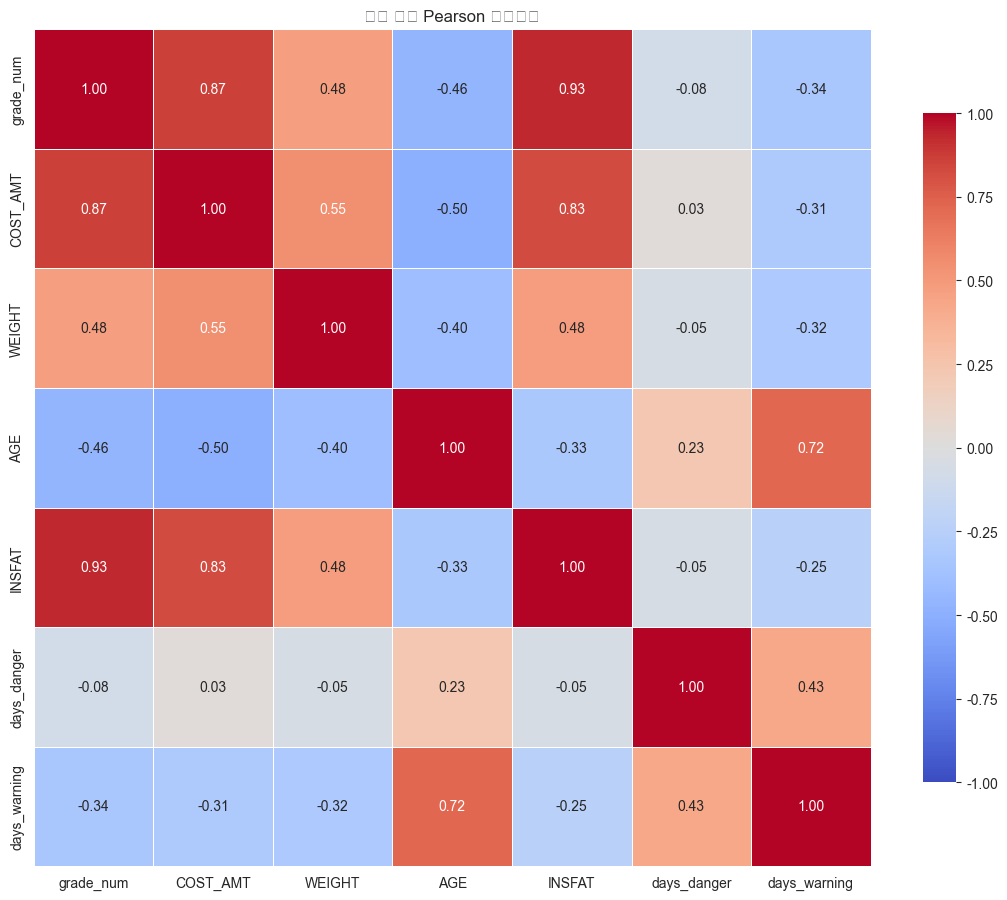

In [28]:
# ==============================================================
# 핵심 변수 히트맵 (셀9)
# ==============================================================
# ==============================================================
# grade_num(등급) 기준으로
# INSFAT(근내지방도가 높을수록 등급 좋음) 0.93
# 등급이 좋을수록 COST_AMT(가격)도 높음 0.87
# WEIGHT(무게)가 클수록 등급이 좋아지는 경향 0.48
# AGE(나이)가 많을수록 등급 낮아짐 -0.46
# days_경고(경고 일수)가 많을수록 등급 낮아짐 -0.34
# days_위험(위험 일수)와 등급 거의 관계 없음 -0.08
# ==============================================================
corr_key = df[cols_key].corr(method="pearson")
plt.figure(figsize=(11, 9))
sns.heatmap(corr_key, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("핵심 변수 Pearson 상관행렬")
plt.tight_layout()
plt.savefig("../../../figures/correlation/13_corr_key.png", dpi=100, bbox_inches="tight")
plt.show()

In [23]:
rename_map = {
    "days_양호": "days_good",
    "days_주의": "days_caution",
    "days_경고": "days_warning",
    "days_위험": "days_danger",
    "days_폐사": "days_death"
}

df = df.rename(columns=rename_map)
df.to_csv("../../../data/processed/2_preprocess/step6_preprocess_eng.csv",
          index=False, encoding="utf-8-sig")

## 4. 그룹별 히트맵(형질 / 기상 / 농장)

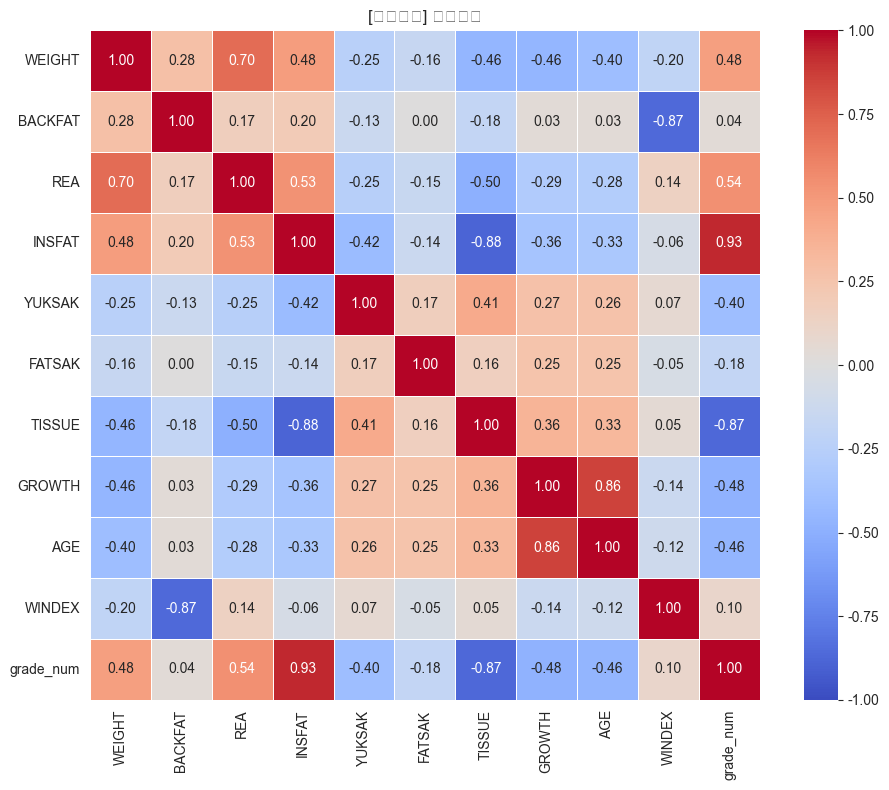

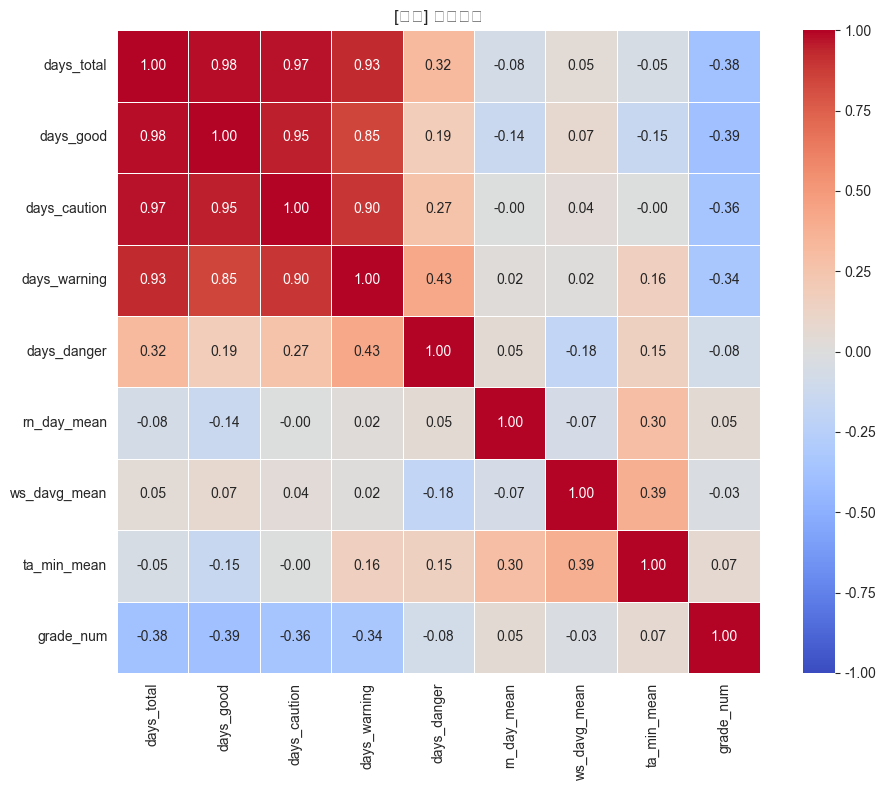

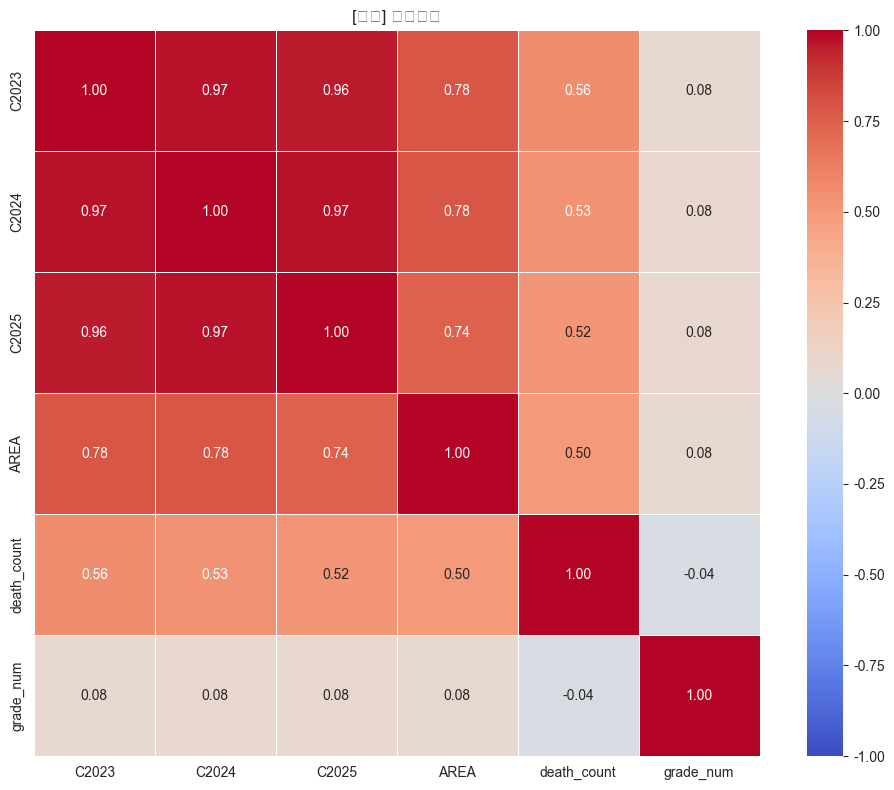

In [29]:
# ==============================================================
# 그룹별 히트맵
# ==============================================================
groups = {
    "한우형질": cols_body + ["grade_num"],
    "기상":     cols_weather + ["grade_num"],
    "농장":     cols_farm + ["grade_num"],
}
for name, cols in groups.items():
    #실세 존재하는 컬럼만 남기기
    cols = existing(list(dict.fromkeys(cols)))
    #컬럼 3개보다 적으면 히트맵 의미 약해서 그 그룹은 스킵
    if len(cols) < 3:
        continue
    #피어슨 상관행렬 계산
    corr = df[cols].corr(method="pearson")
    #그림 크기 설정
    plt.figure(figsize=(10, 8))
    #히트맵 그리기
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title(f"[{name}] 상관행렬")
    #축 이름,제목이 잘리지않게 정리
    plt.tight_layout()
    plt.savefig(f"../figures/13_corr_{name}.png", dpi=100, bbox_inches="tight")
    plt.show()